# Create Images of Ship Sprites

In [148]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [149]:
import re
from colors_map import *

sprites_files = ["uridium/src/ship_sprites.asm"]
sprites_data = {}
sprites_bytes = {}
sprites_ram = {}
sprites_offset = {}
sprite_orientation = {}
sprite_ram = 0x5000
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    sprite_bytes = ""
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
                sprites_bytes[sprite_name] = sprite_bytes
                sprites_ram[sprite_name] = hex(sprite_ram)[2:].upper()
                sprite_ram += 0x40
            sprite_name = l[22:36].strip()
            sprite_orientation[sprite_name] = (l[42:45],l[51:54],l[60:63],)
            sprites_offset[sprite_name] = l[18:20]
            sprite_data = []
            sprite_bytes = ""
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
        sprite_bytes += l[10:21]+'\n'
    if sprite_data:
        sprites_data[sprite_name] = sprite_data
        sprites_bytes[sprite_name] = sprite_bytes
        sprites_ram[sprite_name] = hex(sprite_ram)[2:].upper()

Function for actually drawing the sprite

In [150]:
from PIL import Image, ImageDraw, ImageColor, ImageFont
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40


def paintSprite(sprite_data, colors):
    (background, background_text), (multicol0, multicol0_text), (multicol1,multicol1_text), (color, color_text) = colors
    colormap = {
        "00": background,
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    text_colormap = {
        "00": background_text,
        "01": multicol0_text,
        "10": color_text,
        "11": multicol1_text,
    }
    
    image_width = CELL_WIDTH*SPRITE_COLS
    image_height = CELL_HEIGHT*SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    bit_array = sprite_data
    # Remember that each bitpair in the bit_array is duplicated.
    # e.g. 01 appears as 01,01 so that we can treat each element as
    # a single bit.
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit[(x%2)] # Get the correct side of the bitpair
            draw.text((X+10, Y-8), b, font=fnt, fill=text_colormap[bit])
    return img


In [201]:
byte_literals = """.BYTE
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
"""

colors = (
    # cell color, text color
    ("c64_gray3", "white"),
    ("c64_yellow", "darkgray"),
    ("c64_white", "gray"),
    ("c64_black", "darkgray"),
)
sprite_name = "MANTA_LEFT_9"

def generateSpriteDiagram(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors)

    img = Image.new('RGBA', (1530,900))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/MANTA/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (35,294))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (80,-440))


    # Sprite orientation
    azimuth, roll, elevation = sprite_orientation[sprite_name]
    label_text = f"AZIMUTH:{azimuth}°    ELEVATION:{elevation}°    ROLL:{roll}°"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (120,-440))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size - 10)
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2][0]])
    draw.rectangle([(210,6), (229,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (160,860))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (490,860))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (850,860))


    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (1140,8))

    # Sprite bytes
    label_text = sprite_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (1260,8))

    # Main Sprite image
    img.paste(sprite_img, (160,10))

    # Byte delimiter ticks
    draw = ImageDraw.Draw(img)
    vectors = [
        ((480,0), (480,10)), 
        ((800,0), (800,10)),
        #((450,850), (450,865)), 
        #((770,850), (770,865)),
    ]
    for start,end in vectors:
        draw.line((start,end), width=3, fill="black")
    return img

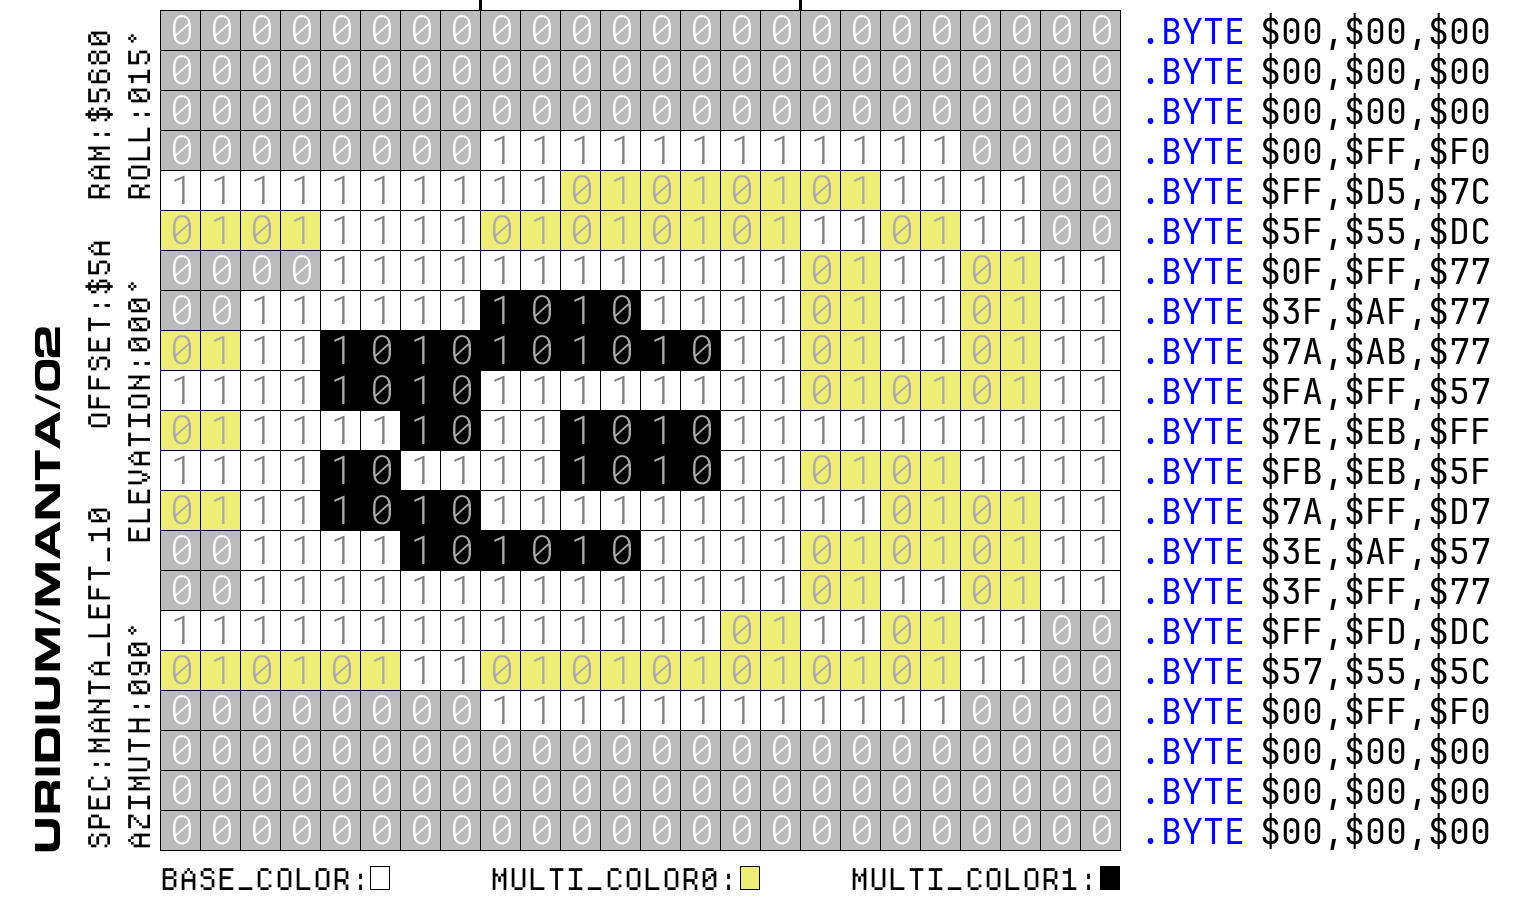

In [202]:
generateSpriteDiagram("MANTA_LEFT_10", 2)


In [203]:
for entry_num, sprite_name in enumerate(sprites_data):
    if not sprite_name:
        continue
    img = generateSpriteDiagram(sprite_name, entry_num)
    img.save(f"sprite_diagrams/{sprite_name}.png")
    img.save(f"sprite_diagrams_list/MANTA_{entry_num}.png")

# Scratchpad

In [3]:
from PIL import Image, ImageColor

def paintSprite(origin, img, sprite, colors):
    multicol0, multicol1,color = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    pixels = img.load()
    x_o, y_o = origin
    if sprite not in sprites_data:
        return
    bit_array = sprites_data[sprite]
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(fhex_to_rgb[colormap[bit]])
            pixels[x_o+x, y_o+y] = pixel_color
    return img


Write out the sprites to image files

In [68]:
import os
from collections import defaultdict
from sprite_map import sprite_map 
from colors_map import *

bits=8
width = 24
height = 21

for j, mvt in enumerate(movements):
    for i,(sprite, _origin, (_planet,_level), colors) in enumerate(mvt):
        if sprite not in sprite_map:
            continue
        sprite_name = sprite_map[sprite]
        #fname = f'sprites-gallery/sprite_{sprite_name}_{"".join(colors)}.png'
        fname = f'sprites-gallery/sprite_{int(sprite,16)}.png'
        if os.path.isfile(fname):
            continue
        img = Image.new( 'RGBA', (width,height))
        origin = (0,0)
        img = paintSprite(origin, img, sprite, colors)
        bkg = surfaces[_planet]
        bkg.paste(img, (5,5))
        bkg = bkg.resize((bkg.width * 10, bkg.height * 10), Image.NEAREST)
        bkg.save(fname)

for sprite in sprites_data:
    fname = f'sprites-gallery/sprite_{int(sprite,16)}.png'
    if os.path.isfile(fname):
        continue
    img = Image.new( 'RGBA', (width,height))
    origin = (0,0)
    img = paintSprite(origin, img, sprite, colors)
    bkg = surfaces[_planet]
    bkg.paste(img, (5,5))
    bkg = bkg.resize((bkg.width * 10, bkg.height * 10), Image.NEAREST)
    bkg.save(fname)



a0
a1
a2
a3
a4
a5
a6
a7
a8
a9
aa
ab
ac
ad
ae
af
b0
b1
b2
b3
b4
b5
b6
b7
b8
b9
ba
bb
bc
bd
be
bf
c0
c1
c2
c3
c4
c5
c6
c7
c8
c9
ca
cb
cc
cd
ce
cf
d0
d1
d2
d3
d4
d5
d6
d7
d8
d9
da
db
dc
Doing dc
dd
Doing dd
de
df
Doing df
e0
e1
Doing e1
e2
Doing e2
e3
e4
e5
e6
e7
e8
e9
ea
eb
ec
ed
ee
ef
f0
f1
Doing f1
f2
Doing f2
f3
Doing f3
f4
f5
Doing f5
f6
f7
f8
f9
fa
fb
fc
fd
fe
ff
00
Doing 00
01
Doing 01
02
Doing 02
03
Doing 03
04
Doing 04
05
Doing 05
06
Doing 06
07
Doing 07
08
Doing 08
09
Doing 09
0a
Doing 0a
0b
Doing 0b
21
22
23
24
25
26
27
28
29
2a
2b
2c
2d
2e
2f
30
31
32
33
34
35
36
37
38
39
3a
3b
3c
3d
3e
3f
